In [1]:
import sys
sys.path.append("/work/M6_Project_Anti_Food_Waste")

import glob
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    classification_report,
    precision_recall_curve, average_precision_score,
    roc_auc_score,
)
from config import MODELS_DIR, FEATURES_DIR, PREDICTION_THRESHOLD

In [2]:
# Latest test split — already fully preprocessed (encoded + scaled), includes will_sell label
test_file = sorted(glob.glob(str(FEATURES_DIR / "test_*.parquet")))[-1]
print(f"Loading: {test_file}")

test   = pd.read_parquet(test_file)
X_test = test.drop(columns=["will_sell"])
y_test = test["will_sell"]

model = joblib.load(MODELS_DIR / "model.joblib")

print(f"Test set:      {len(test):,} rows")
print(f"Positive rate: {y_test.mean():.1%}")
print(f"Features:      {X_test.shape[1]}")

Loading: /work/M6_Project_Anti_Food_Waste/data/features/test_20260603.parquet
Test set:      112,033 rows
Positive rate: 44.4%
Features:      68


In [3]:
X_test.columns

Index(['offer_original_price', 'offer_new_price', 'offer_discount',
       'offer_percent_discount', 'store_name', 'store_brand', 'initial_stock',
       'offer_total_duration', 'hours_since_start', 'hours_until_offer_end',
       'pct_time_elapsed', 'stock_drop_so_far', 'pct_stock_drop_so_far',
       'stock_drop_per_hour', 'category_level1_en', 'category_level2_en',
       'category_level3_en', 'category_level4_en', 'category_level3_da',
       'category_level4_da', 'flow_peak_value', 'flow_avg',
       'flow_at_offer_start', 'flow_at_snapshot_hour', 'flow_remaining_avg',
       'flow_evening_share', 'store_open_hours', 'hours_until_close',
       'is_closed_tomorrow', 'flow_peak_hour_0', 'flow_peak_hour_11',
       'flow_peak_hour_12', 'flow_peak_hour_13', 'flow_peak_hour_14',
       'flow_peak_hour_15', 'flow_peak_hour_16', 'flow_peak_hour_17',
       'flow_peak_hour_18', 'flow_peak_hour_21', 'flow_peak_hour_22',
       'flow_peak_hour_23', 'offer_start_dayofweek_0',
       'offer_

In [4]:
y_prob = model.predict_proba(X_test)[:, 1]
y_pred = (y_prob >= PREDICTION_THRESHOLD).astype(int)

print(f"Threshold:              {PREDICTION_THRESHOLD}")
print(f"Predicted will_sell=1:  {y_pred.sum():,} ({y_pred.mean():.1%})")
print(f"Actual    will_sell=1:  {y_test.sum():,} ({y_test.mean():.1%})")

Threshold:              0.5
Predicted will_sell=1:  43,420 (38.8%)
Actual    will_sell=1:  49,724 (44.4%)


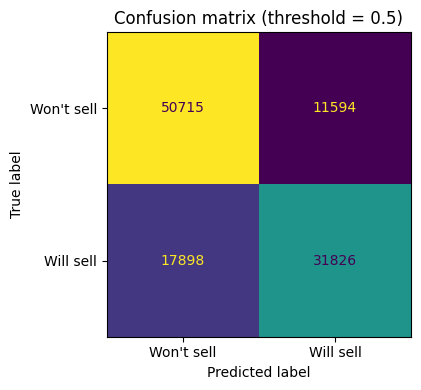

In [5]:
cm   = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=["Won't sell", "Will sell"])

fig, ax = plt.subplots(figsize=(5, 4))
disp.plot(ax=ax, colorbar=False)
ax.set_title(f"Confusion matrix (threshold = {PREDICTION_THRESHOLD})")
plt.tight_layout()
plt.show()

In [6]:
print(classification_report(y_test, y_pred, target_names=["Won't sell", "Will sell"]))

              precision    recall  f1-score   support

  Won't sell       0.74      0.81      0.77     62309
   Will sell       0.73      0.64      0.68     49724

    accuracy                           0.74    112033
   macro avg       0.74      0.73      0.73    112033
weighted avg       0.74      0.74      0.73    112033



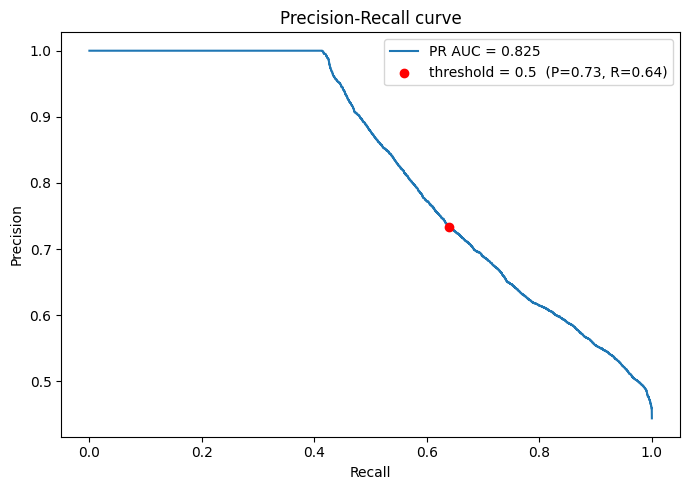

ROC AUC: 0.8174
PR AUC:  0.8253


In [7]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)
ap  = average_precision_score(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

threshold_idx = np.argmin(np.abs(thresholds - PREDICTION_THRESHOLD))

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(recall, precision, label=f"PR AUC = {ap:.3f}")
ax.scatter(
    recall[threshold_idx], precision[threshold_idx],
    color="red", zorder=5,
    label=f"threshold = {PREDICTION_THRESHOLD}  (P={precision[threshold_idx]:.2f}, R={recall[threshold_idx]:.2f})",
)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("Precision-Recall curve")
ax.legend()
plt.tight_layout()
plt.show()

print(f"ROC AUC: {auc:.4f}")
print(f"PR AUC:  {ap:.4f}")

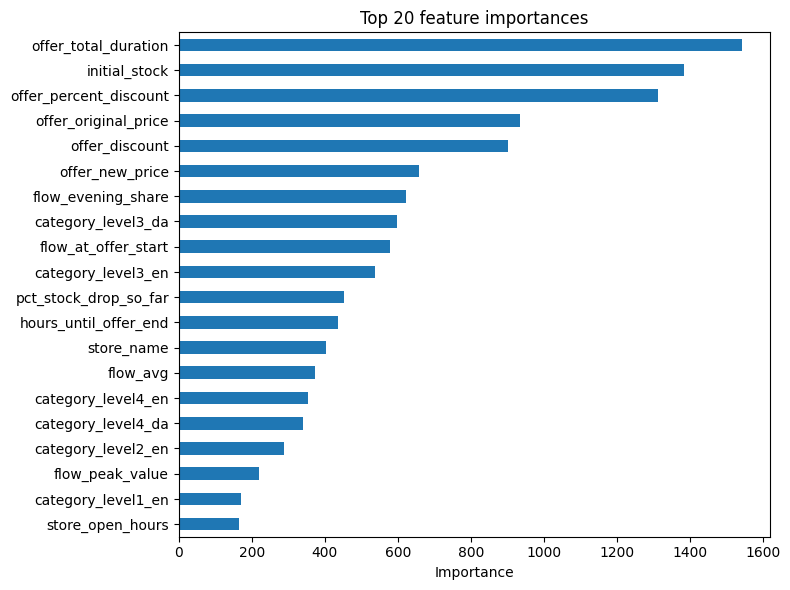

In [8]:
# Feature importances (tree-based models only)
if hasattr(model, "feature_importances_"):
    importances = pd.Series(model.feature_importances_, index=X_test.columns)
    top20 = importances.sort_values(ascending=False).head(20)

    fig, ax = plt.subplots(figsize=(8, 6))
    top20.sort_values().plot.barh(ax=ax)
    ax.set_title("Top 20 feature importances")
    ax.set_xlabel("Importance")
    plt.tight_layout()
    plt.show()
else:
    print("Model does not expose feature_importances_ — skipping")

In [9]:
diag = X_test.copy()
diag["y_true"] = y_test.values
diag["y_prob"] = y_prob

high_conf = diag[(diag["y_true"] == 1) & (diag["y_prob"] >= 0.9)]
low_conf  = diag[(diag["y_true"] == 1) & (diag["y_prob"] <  0.9)]

key = ["pct_stock_drop_so_far", "pct_time_elapsed", "stock_drop_per_hour",
       "hours_until_offer_end", "initial_stock"]

print(f"High-confidence positives (≥0.9): {len(high_conf):,}")
print(f"Low-confidence positives  (<0.9): {len(low_conf):,}\n")
print(pd.DataFrame({
    "high_conf_mean": high_conf[key].mean(),
    "low_conf_mean":  low_conf[key].mean(),
}).round(3))


High-confidence positives (≥0.9): 20,858
Low-confidence positives  (<0.9): 28,866

                       high_conf_mean  low_conf_mean
pct_stock_drop_so_far           1.560         -0.153
pct_time_elapsed                0.479         -0.330
stock_drop_per_hour             0.314          0.134
hours_until_offer_end          -0.190         -0.108
initial_stock                  -0.255         -0.211


### Comparing early- mid- and late-stage distribution between training and inference

Skipping (missing columns): scored_20260524_1440.parquet
Skipping (missing columns): scored_20260524_1445.parquet
Skipping (missing columns): scored_20260524_1500.parquet
Skipping (missing columns): scored_20260524_1515.parquet
Skipping (missing columns): scored_20260524_1530.parquet
Skipping (missing columns): scored_20260524_1545.parquet
Skipping (missing columns): scored_20260524_1600.parquet
Skipping (missing columns): scored_20260524_1615.parquet
Skipping (missing columns): scored_20260524_1630.parquet
Skipping (missing columns): scored_20260524_1645.parquet
Skipping (missing columns): scored_20260524_1700.parquet
Skipping (missing columns): scored_20260524_1715.parquet
Skipping (missing columns): scored_20260524_1730.parquet
Skipping (missing columns): scored_20260524_1745.parquet
Skipping (missing columns): scored_20260524_1800.parquet
Skipping (missing columns): scored_20260524_1815.parquet
Skipping (missing columns): scored_20260524_1830.parquet
Skipping (missing columns): sco

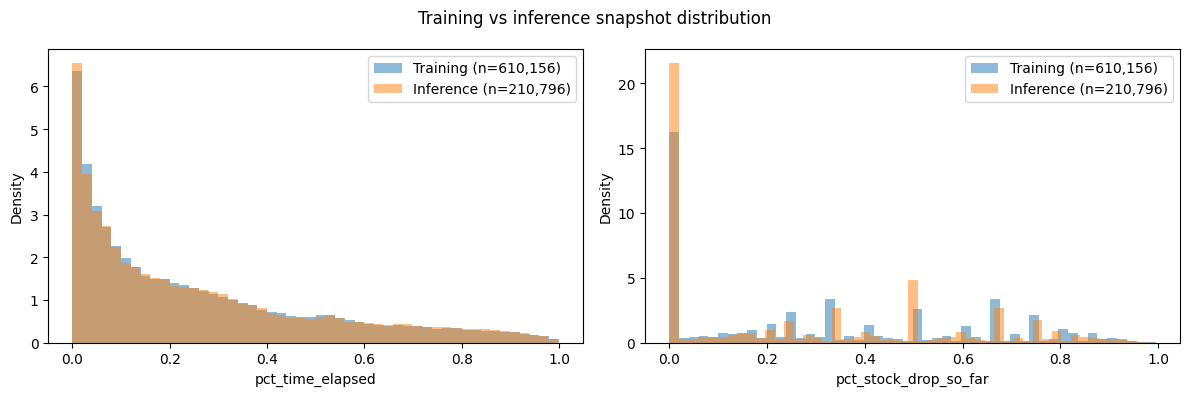


pct_time_elapsed
         training   inference
count  610156.000  210796.000
mean        0.254       0.257
std         0.246       0.249
min         0.000       0.000
25%         0.052       0.053
50%         0.173       0.176
75%         0.388       0.391
max         1.000       0.998

pct_stock_drop_so_far
         training   inference
count  610156.000  210796.000
mean        0.314       0.272
std         0.296       0.294
min         0.000       0.000
25%         0.000       0.000
50%         0.250       0.182
75%         0.592       0.500
max         0.995       0.978


In [12]:
from pathlib import Path
from config import FEATURES_DIR, PREDICTIONS_DIR

# Training distribution — raw unscaled features parquet
train_raw = pd.read_parquet(
    sorted(glob.glob(str(FEATURES_DIR / "features_*.parquet")))[-1],
    columns=["pct_time_elapsed", "pct_stock_drop_so_far"],
)

# Inference distribution — read predictions parquets defensively
pred_files = sorted(glob.glob(str(PREDICTIONS_DIR / "scored_*.parquet")))
frames = []
for f in pred_files:
    try:
        df = pd.read_parquet(f)
        if "pct_time_elapsed" in df.columns and "pct_stock_drop_so_far" in df.columns:
            frames.append(df[["pct_time_elapsed", "pct_stock_drop_so_far"]])
        else:
            print(f"Skipping (missing columns): {Path(f).name}")
    except Exception as e:
        print(f"Skipping (unreadable): {Path(f).name} — {e}")

if not frames:
    print("No valid predictions parquets found")
else:
    inf_raw = pd.concat(frames, ignore_index=True)
    print(f"Loaded {len(inf_raw):,} inference rows from {len(frames)} files")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    for ax, col in zip(axes, ["pct_time_elapsed", "pct_stock_drop_so_far"]):
        ax.hist(train_raw[col], bins=50, density=True, alpha=0.5, label=f"Training (n={len(train_raw):,})")
        ax.hist(inf_raw[col],   bins=50, density=True, alpha=0.5, label=f"Inference (n={len(inf_raw):,})")
        ax.set_xlabel(col)
        ax.set_ylabel("Density")
        ax.legend()

    fig.suptitle("Training vs inference snapshot distribution")
    plt.tight_layout()
    plt.show()

    for col in ["pct_time_elapsed", "pct_stock_drop_so_far"]:
        print(f"\n{col}")
        print(pd.DataFrame({
            "training":  train_raw[col].describe(),
            "inference": inf_raw[col].describe(),
        }).round(3))


Using: scored_20260603_1145.parquet (530 offers)


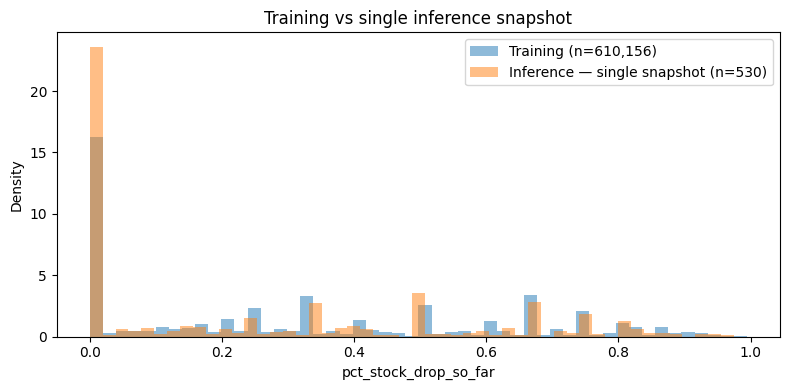

         training  inference
count  610156.000    530.000
mean        0.314      0.253
std         0.296      0.293
min         0.000      0.000
25%         0.000      0.000
50%         0.250      0.118
75%         0.592      0.500
max         0.995      0.975


In [16]:
# Fixed inference snapshot — update this path intentionally if you want a different run
INFERENCE_SNAPSHOT = PREDICTIONS_DIR / "scored_20260603_1145.parquet"

inf_single = pd.read_parquet(INFERENCE_SNAPSHOT, columns=["pct_stock_drop_so_far"])
print(f"Using: {INFERENCE_SNAPSHOT.name} ({len(inf_single):,} offers)")

fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(train_raw["pct_stock_drop_so_far"], bins=50, density=True, alpha=0.5, label=f"Training (n={len(train_raw):,})")
ax.hist(inf_single["pct_stock_drop_so_far"], bins=50, density=True, alpha=0.5, label=f"Inference — single snapshot (n={len(inf_single):,})")
ax.set_xlabel("pct_stock_drop_so_far")
ax.set_ylabel("Density")
ax.set_title("Training vs single inference snapshot")
ax.legend()
plt.tight_layout()
plt.show()

print(pd.DataFrame({
    "training":  train_raw["pct_stock_drop_so_far"].describe(),
    "inference": inf_single["pct_stock_drop_so_far"].describe(),
}).round(3))

